# Loading librairies, model and dataset

In [1]:
from torch.utils.data import DataLoader

import os, time, datetime

import sys
sys.path.append('../../py_scripts')

from SPAC_Dataset import dataset
from models import *

# CuDNN optimisation
torch.backends.cudnn.benchmark = True

main_dir = "/home/amergez/SPA-C/"
data_dir = os.path.join(main_dir, "datasets_v2", "CHM13.DS", "CHM13.DS_5K10S_Q0.hdf5")

weights = "/home/amergez/SPA-C/models/FF.105Logits/FF.105Logits.Classifier.E02.pth"


print("--- Directories ---")
print("Main :", main_dir)
print("Data :", data_dir)

# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

model = SPAC(
    device=device,
    name="SPA-C",
    latent_width=64,
    input_shape=(1, 20, 20)
)

model.load_weights(weights)

--- Directories ---
Main : /home/amergez/SPA-C/
Data : /home/amergez/SPA-C/datasets_v2/CHM13.DS/CHM13.DS_5K10S_Q0.hdf5
Using cuda device
Weights loaded !


In [3]:
HG002 = dataset(
    "/home/amergez/SPA-C/datasets_v2/HG002.B10M/SPA-C_ds/HG002.B10M.scaff_only.hdf5",
    bin_size=5000,
    image_size=10,
    skip_check=True
)
HG002.minmax(max_val=47.0)
HG002.summary()

hg002_dataloader = DataLoader(HG002.get_as_torch(), batch_size=256, shuffle=False, num_workers=12, pin_memory=True)

DLScaff dataset v5.7

Loading /home/amergez/SPA-C/datasets_v2/HG002.B10M/SPA-C_ds/HG002.B10M.scaff_only.hdf5 ...
Done ! (1.148s)

Dataset metadata :
	Cool2InterM_FullMat.creation_date: 01/27/2026-15:05:19
	Cool2InterM_FullMat.filter: None
	Cool2InterM_FullMat.version: 1.11
	data.type: Inter.FullMat
	dataset: HG002.B10M.JHE

'HG002.B10M.JHE' dataset summary - BS:5000 IS:10

	The dataset has been normed.
	Whole dataset :
		x - (344568, 20, 20)
		y - (344568,)
		names - (344568,)
		groups - (344568,)
		0.0% of the samples are True


# Prediction

In [4]:
#% Copied from eval method of SPA-C class of model.py
model.model.eval()

### MASKING -------------------------------------------------------------------------------------------------------
for k in range(1,9): # Size of the masked area
    for positions in [(0,k), (20-k, 20)]: # Start, then end masked area 
        pos = "S" if positions[0] == 0 else "E"
        # Creating list to store predictions, raw outputs and labels
        all_probs = []
        all_labels = []
        all_names = []
        
        with torch.no_grad():
            with tqdm(hg002_dataloader, unit="batch") as tepoch:
                for x, y in tepoch:
                    tepoch.set_description(f"Predicting on test @ Masked {pos}{k}")
                    x = x.to(model.device)

                    # Masking positions
                    x[:,:,positions[0]:positions[1],:] = -1
                    x[:,:,:,positions[0]:positions[1]] = -1
                    
                    # print(x[0][0])
                    # plt.matshow(x.cpu()[0][0])
                    # plt.show()
                    # plt.close()
                    
                    outputs = torch.sigmoid(model.model(x))
        
                    all_probs.append(outputs.cpu())
                    all_labels.append(y.cpu())
                    
        
        # Concatenating predictions, raw outputs and labels
        all_probs = torch.cat(all_probs).numpy()
        all_labels = torch.cat(all_labels).numpy()
        
        # Exporting predictions to JSON
        prob_dict = {f"{HG002.N[i]}%Masked_{pos}{k}": float(all_probs[i][0]) for i in range(len(HG002.N))}
        
        with open(f"HG002.B10M.Masked_{pos}{k}.Pred.json", "w") as handle:
            json.dump(
                prob_dict,
                handle,
                indent=2
            )

### PADDING -------------------------------------------------------------------------------------------------------
for k in range(1,9): # Size of the masked area
    for positions in [(0,k), (20-k, 20)]: # Start, then end masked area 
        pos = "S" if positions[0] == 0 else "E"
        # Creating list to store predictions, raw outputs and labels
        all_probs = []
        all_labels = []
        all_names = []
        
        with torch.no_grad():
            with tqdm(hg002_dataloader, unit="batch") as tepoch:
                for x, y in tepoch:
                    tepoch.set_description(f"Predicting on test @ Padded {pos}{k}")
                    x = x.to(model.device)

                    # Masking positions
                    x[:,:,positions[0]:positions[1],:] = 0
                    x[:,:,:,positions[0]:positions[1]] = 0
                    
                    # print(x[0][0])
                    # plt.matshow(x.cpu()[0][0])
                    # plt.show()
                    # plt.close()
                    
                    outputs = torch.sigmoid(model.model(x))
        
                    all_probs.append(outputs.cpu())
                    all_labels.append(y.cpu())
                    
        
        # Concatenating predictions, raw outputs and labels
        all_probs = torch.cat(all_probs).numpy()
        all_labels = torch.cat(all_labels).numpy()
        
        # Exporting predictions to JSON
        prob_dict = {f"{HG002.N[i]}%Padded_{pos}{k}": float(all_probs[i][0]) for i in range(len(HG002.N))}
        
        with open(f"HG002.B10M.Padded_{pos}{k}.Pred.json", "w") as handle:
            json.dump(
                prob_dict,
                handle,
                indent=2
            )

Predicting on test @ Padded E8: 100%|███████████████████████████████████████████████████████████████████████████████| 1346/1346 [00:06<00:00, 213.41batch/s]


In [5]:
def start_or_end(pos):
    if pos == 0: return "Start"
    return "End"

# Building the prob net
def get_inter_probs(probs):
    prob_net = {}
    for ctg, prob in probs.items():
        # Decomposing contig name
        try:
            start_part, end_part = ctg.split("%")[0].split("|")
            start_ctg, start_pos = start_part.rsplit(':', 1)
            end_ctg, end_pos = end_part.rsplit(':', 1)
            start_pos, end_pos = start_or_end(int(start_pos)), start_or_end(int(end_pos))
    
        except Exception as E:
            continue

        if not (end_ctg, start_ctg) in prob_net.keys():
            main_key = (start_ctg, end_ctg)
            second_key = (start_pos, end_pos)
        else:
            main_key = (end_ctg, start_ctg)
            second_key = (end_pos, start_pos)
    
        try:
            prob_net[main_key][second_key] = (prob + prob_net[main_key][second_key]) / 2
        except:
            try:
                prob_net[main_key][second_key] = prob
            except:
                prob_net[main_key] = {second_key: prob}
    
    return prob_net

def is_contiguous(key):
    chromA, orderA = key[0].split(":")[0].rsplit("_", 1)
    chromB, orderB = key[1].split(":")[0].rsplit("_", 1)

    if (chromA == chromB):
        diff = ord(orderA) - ord(orderB)
        if diff == -1:
            return True, "F"
        elif diff == 1:
            return True, "R"
    return False, None

# Data processing

## Masking

In [6]:
import json

subset_list = [f"HG002.B10M.Masked_{pos}{k}.Pred.json" for pos in ["E","S"] for k in range(1,9)]

inter_probs = {}

for ds_name in subset_list:
    key = ds_name.split("_")[1].split(".")[0]
    inter_probs[key] = None
    with open(ds_name, "r") as handle:
        probs = json.load(handle)
    if inter_probs[key] is None:
        inter_probs[key] = get_inter_probs(probs)
    else:
        add_probs = get_inter_probs(probs)
        inter_probs[key].update(add_probs)

orient_eq = {"F":("End","Start"), "R":("Start","End")}
res_dict = {
        "padding": [],
        "e_correct": [],
        "e_incorrect": [],
        "s_correct": [],
        "s_incorrect": []
    }
for k in range(1,9):
    for key, values in inter_probs[f"E{k}"].items():
        contiguous, strand = is_contiguous(key)

        for orient, prob in values.items():
            res_dict["padding"].append(k)
            res_dict["s_correct"].append(np.nan)
            res_dict["s_incorrect"].append(np.nan)
            if contiguous and orient == orient_eq[strand]:
                res_dict["e_correct"].append(prob)
                res_dict["e_incorrect"].append(np.nan)
            else:
                res_dict["e_incorrect"].append(prob)
                res_dict["e_correct"].append(np.nan)
                
    for key, values in inter_probs[f"S{k}"].items():
        contiguous, strand = is_contiguous(key)

        for orient, prob in values.items():
            res_dict["padding"].append(k)
            res_dict["e_correct"].append(np.nan)
            res_dict["e_incorrect"].append(np.nan)
            if contiguous and orient == orient_eq[strand]:
                res_dict["s_correct"].append(prob)
                res_dict["s_incorrect"].append(np.nan)
            else:
                res_dict["s_incorrect"].append(prob)
                res_dict["s_correct"].append(np.nan)

import pandas as pd
df = pd.DataFrame.from_dict(res_dict, orient="columns")
df['correct'] = df['e_correct'].combine_first(df['s_correct'])
df['incorrect'] = df['e_incorrect'].combine_first(df['s_incorrect'])
df

,padding,e_correct,e_incorrect,s_correct,s_incorrect,correct,incorrect
0,1,NaN,1.745363e-07,NaN,NaN,NaN,1.745363e-07
1,1,NaN,1.989147e-06,NaN,NaN,NaN,1.989147e-06
2,1,0.999815,NaN,NaN,NaN,0.999815,NaN
3,1,NaN,7.493189e-09,NaN,NaN,NaN,7.493189e-09
4,1,NaN,2.326788e-06,NaN,NaN,NaN,2.326788e-06
...,...,...,...,...,...,...,...
2756539,8,NaN,NaN,NaN,0.045087,NaN,4.508687e-02
2756540,8,NaN,NaN,NaN,0.010928,NaN,1.092775e-02
2756541,8,NaN,NaN,NaN,0.021793,NaN,2.179299e-02
2756542,8,NaN,NaN,0.787913,NaN,0.787913,NaN


In [7]:
# Dataset
df_list = []
for col in ["correct", "incorrect"]: #["e_correct", "e_incorrect", "s_correct", "s_incorrect"]: #
    _ = df[['padding', col]].dropna().rename(columns={col: 'prediction'})
    _['type'] = f"{col.capitalize()} join"
    df_list.append(_)

df_melted = pd.concat(df_list, ignore_index=True)
df_melted

,padding,prediction,type
0,1,0.999815,Correct join
1,1,0.999959,Correct join
2,1,0.999986,Correct join
3,1,0.999954,Correct join
4,1,0.999979,Correct join
...,...,...,...
2756539,8,0.018988,Incorrect join
2756540,8,0.045087,Incorrect join
2756541,8,0.010928,Incorrect join
2756542,8,0.021793,Incorrect join


In [8]:
df_melted.groupby('type')['prediction'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Correct join,4336.0,0.931740,0.124444,1.805653e-01,8.487954e-01,0.999093,0.999788,0.999997
Incorrect join,2752208.0,0.005169,0.037690,7.986858e-11,2.949779e-07,0.000004,0.000116,0.999808


In [9]:
from sklearn.metrics import roc_auc_score, average_precision_score

AUPRs_masking = []

for pad in df_melted.padding.unique():
    print(pad)
    _df = df_melted[df_melted.padding == pad]

    _labels = (_df.type == "Correct join").astype(int).to_numpy()
    _preds = (_df.prediction).to_numpy()

    AUPRs_masking.append(average_precision_score(_labels, _preds, average='weighted'))
    print(AUPRs_masking[-1])

1
0.9839931524755546
2
0.9831237466783738
3
0.9846071588343106
4
0.984177793406263
5
0.9810351201680857
6
0.9794720486331312
7
0.7931274641272706
8
0.6273485685147568


## Padding

In [10]:
import json

subset_list = [f"HG002.B10M.Padded_{pos}{k}.Pred.json" for pos in ["E","S"] for k in range(1,9)]

inter_probs = {}

for ds_name in subset_list:
    key = ds_name.split("_")[1].split(".")[0]
    inter_probs[key] = None
    with open(ds_name, "r") as handle:
        probs = json.load(handle)
    if inter_probs[key] is None:
        inter_probs[key] = get_inter_probs(probs)
    else:
        add_probs = get_inter_probs(probs)
        inter_probs[key].update(add_probs)

orient_eq = {"F":("End","Start"), "R":("Start","End")}
res_dict = {
        "padding": [],
        "e_correct": [],
        "e_incorrect": [],
        "s_correct": [],
        "s_incorrect": []
    }
for k in range(1,9):
    for key, values in inter_probs[f"E{k}"].items():
        contiguous, strand = is_contiguous(key)

        for orient, prob in values.items():
            res_dict["padding"].append(k)
            res_dict["s_correct"].append(np.nan)
            res_dict["s_incorrect"].append(np.nan)
            if contiguous and orient == orient_eq[strand]:
                res_dict["e_correct"].append(prob)
                res_dict["e_incorrect"].append(np.nan)
            else:
                res_dict["e_incorrect"].append(prob)
                res_dict["e_correct"].append(np.nan)
                
    for key, values in inter_probs[f"S{k}"].items():
        contiguous, strand = is_contiguous(key)

        for orient, prob in values.items():
            res_dict["padding"].append(k)
            res_dict["e_correct"].append(np.nan)
            res_dict["e_incorrect"].append(np.nan)
            if contiguous and orient == orient_eq[strand]:
                res_dict["s_correct"].append(prob)
                res_dict["s_incorrect"].append(np.nan)
            else:
                res_dict["s_incorrect"].append(prob)
                res_dict["s_correct"].append(np.nan)

import pandas as pd
df = pd.DataFrame.from_dict(res_dict, orient="columns")
df['correct'] = df['e_correct'].combine_first(df['s_correct'])
df['incorrect'] = df['e_incorrect'].combine_first(df['s_incorrect'])
df

,padding,e_correct,e_incorrect,s_correct,s_incorrect,correct,incorrect
0,1,NaN,1.756415e-07,NaN,NaN,NaN,1.756415e-07
1,1,NaN,1.692672e-06,NaN,NaN,NaN,1.692672e-06
2,1,0.999819,NaN,NaN,NaN,0.999819,NaN
3,1,NaN,6.417849e-09,NaN,NaN,NaN,6.417849e-09
4,1,NaN,2.317259e-06,NaN,NaN,NaN,2.317259e-06
...,...,...,...,...,...,...,...
2756539,8,NaN,NaN,NaN,0.002650,NaN,2.650284e-03
2756540,8,NaN,NaN,NaN,0.000924,NaN,9.244748e-04
2756541,8,NaN,NaN,NaN,0.000773,NaN,7.731222e-04
2756542,8,NaN,NaN,0.008648,NaN,0.008648,NaN


In [11]:
# Dataset
df_list = []
for col in ["correct", "incorrect"]: #["e_correct", "e_incorrect", "s_correct", "s_incorrect"]: #
    _ = df[['padding', col]].dropna().rename(columns={col: 'prediction'})
    _['type'] = f"{col.capitalize()} join"
    df_list.append(_)

df_melted = pd.concat(df_list, ignore_index=True)
df_melted

,padding,prediction,type
0,1,0.999819,Correct join
1,1,0.999958,Correct join
2,1,0.999986,Correct join
3,1,0.999956,Correct join
4,1,0.999980,Correct join
...,...,...,...
2756539,8,0.002139,Incorrect join
2756540,8,0.002650,Incorrect join
2756541,8,0.000924,Incorrect join
2756542,8,0.000773,Incorrect join


In [12]:
df_melted.groupby('type')['prediction'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Correct join,4336.0,0.711570,0.418982,3.421820e-06,3.118158e-01,9.791052e-01,0.999559,0.999996
Incorrect join,2752208.0,0.001316,0.021275,4.264803e-12,3.969709e-08,3.760772e-07,0.000009,0.999757


In [13]:
from sklearn.metrics import roc_auc_score, average_precision_score

AUPRs_padding = []

for pad in df_melted.padding.unique():
    print(pad)
    _df = df_melted[df_melted.padding == pad]

    _labels = (_df.type == "Correct join").astype(int).to_numpy()
    _preds = (_df.prediction).to_numpy()

    AUPRs_padding.append(average_precision_score(_labels, _preds, average='weighted'))
    print(AUPRs_padding[-1])

1
0.9838150579731735
2
0.9831983209610743
3
0.9842392052692939
4
0.9688317987181485
5
0.935913191065905
6
0.9363741645909854
7
0.022386152537832393
8
0.004562871174063857


# Figure

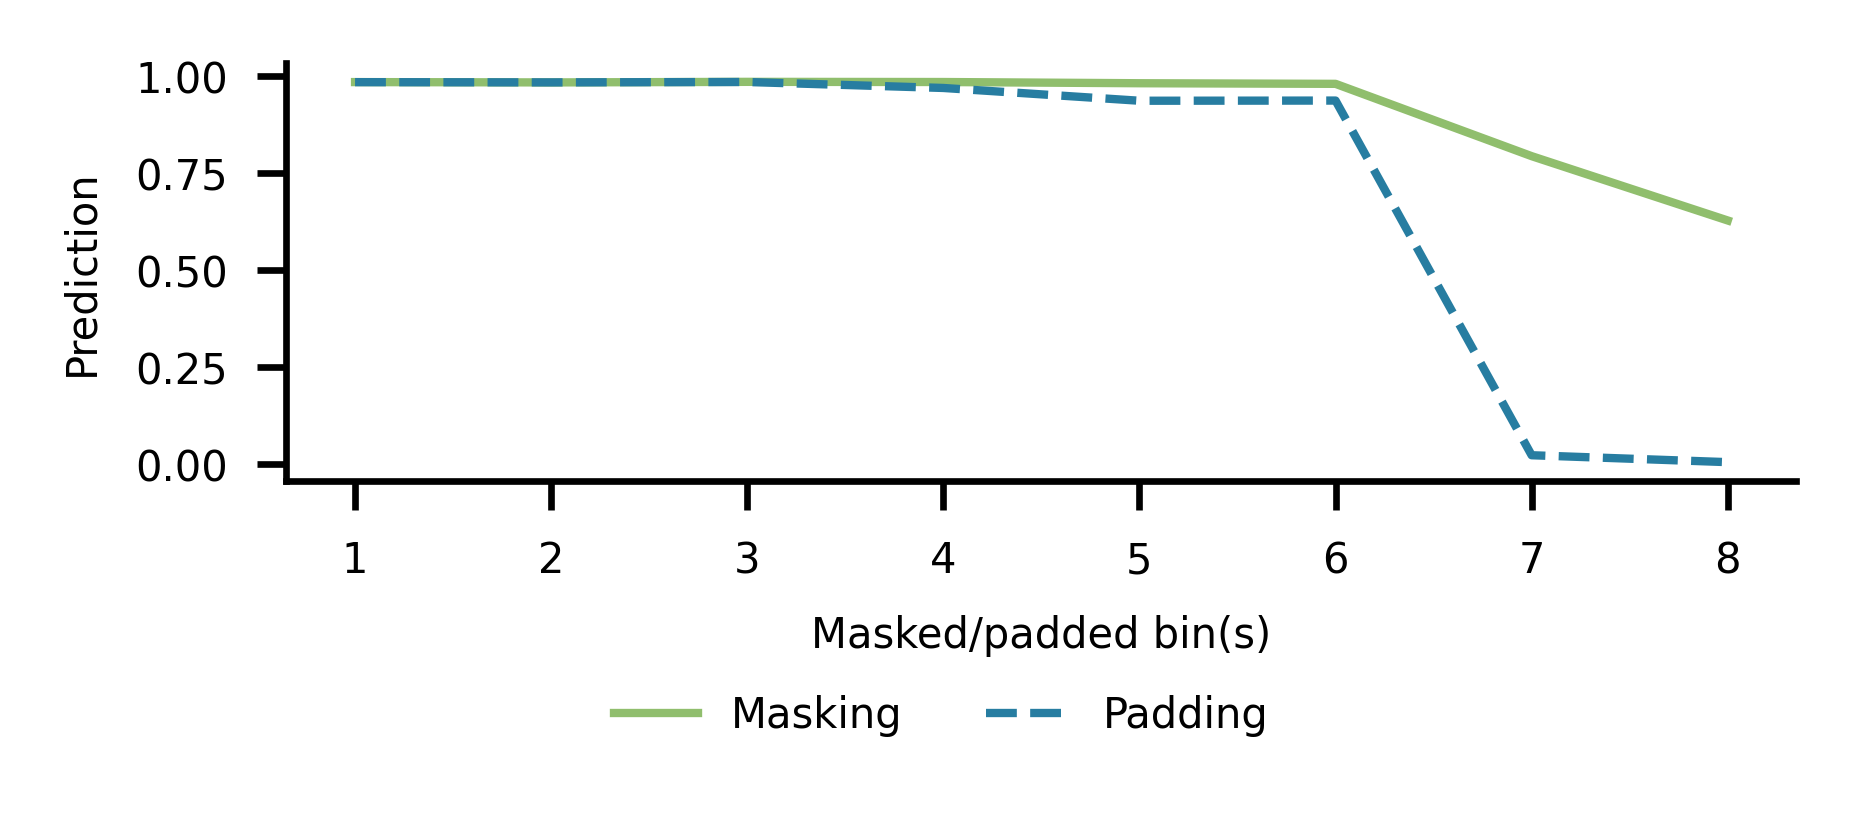

In [14]:
# Figure
import matplotlib.pyplot as plt
import seaborn as sns

fs = 5
plt.rcParams.update({'font.size': fs, 'legend.fontsize':fs, 'figure.labelsize':fs, 'xtick.labelsize': fs, 'ytick.labelsize': fs})

fig, ax = plt.subplots(1,1, figsize=(3, 1.2), dpi=600)
X = list(range(1, 9))
sns.lineplot(x=X, y=AUPRs_masking, ax=ax, color='#90BE6D', label="Masking", linewidth=1)
sns.lineplot(x=X, y=AUPRs_padding, ax=ax, color="#277DA1", label="Padding", linewidth=1, linestyle="--")


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Masked/padded bin(s)', fontdict={"size":fs})
ax.set_ylabel('Prediction', fontdict={"size":fs})

legend = ax.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    frameon=False,
    facecolor='white',
    edgecolor='none'
)
lines, labels = ax.get_legend_handles_labels()
fig.legend(lines, labels, loc='lower center', 
           fontsize=fs, frameon=False, ncols=3, bbox_to_anchor=(.5, -0.05))
ax.legend_.remove()

plt.tight_layout(rect=(0,0.05,1,1))

plt.savefig("PAPER_MASKING.png")

plt.show()